# Anomaly detection

### Four ways to say "this one is not like the others"

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How Isolation Forest, One-Class SVM, Local Outlier Factor and a Gaussian-mixture density each define unusual, how to judge a detector with no labels and how to judge one honestly when you have them, and what the contamination parameter really does |
| **You should already know** | [Gaussian Mixture Models](../05-gaussian-mixture-models/), [density-based clustering](../04-dbscan-and-hdbscan/), [support vector machines](../../03-classification/05-support-vector-machines/), [random forests](../../04-ensembles/02-random-forest/) |
| **Datasets** | UCI Dry Bean, Wisconsin Breast Cancer, plus blobs with uniform noise scattered over them |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [05-07 Association rules with Apriori](../07-association-rules/) |

---

## 1. The idea

Every method so far wanted examples of each class. Anomaly detection is for the
case where you have a great deal of the ordinary, almost none of the strange, and
no guarantee that the strange thing you actually care about has happened yet. A
classifier trained on last year's fraud learns last year's fraud. A detector
trained on normal behaviour flags anything that does not look like it, including
the kind nobody has seen.

So the shape of the problem changes. Instead of learning a boundary between two
labelled groups, I learn a description of **normal** and measure how far each row
falls from it. Every method in this notebook produces one number per row, and the
number means the same thing in all four cases: bigger is stranger. What differs is
the definition of "far".

An **Isolation Forest** asks how few random cuts it takes to separate this point
from the rest. A **One-Class SVM** asks whether the point falls outside a boundary
drawn tightly around the training data. **Local Outlier Factor** asks whether the
point sits in a thinner patch than its own neighbours sit in. A **Gaussian
mixture** asks how unlikely the point is under a density fitted to the data.

Those are four genuinely different questions, so the four answers often disagree.
I will spend the last section on that disagreement, because it is the most useful
output of the whole exercise, and on `contamination`, the parameter where you tell
the model how many anomalies to find and then congratulate it for finding that
many.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. How each one defines unusual

| Detector | Calls a point unusual when | Wants | Struggles when |
|---|---|---|---|
| Isolation Forest | random splits cut it off from the rest in few steps | nothing much, and no scaling at all | the point is only odd in a *combination* of features that no single axis exposes |
| One-Class SVM | it lands outside a boundary wrapped around the training data | scaled features, a sensible `gamma`, a few thousand rows at most | the data is large, because fitting is quadratic in rows |
| Local Outlier Factor | its neighbourhood is thinner than its neighbours' neighbourhoods | scaled features and a value of $k$ | the right $k$ differs across the dataset |
| Gaussian mixture | the fitted density assigns it a low likelihood | scaled features and enough rows per dimension | the data is not shaped like a handful of ellipses |

The maths, in one line each.

**Isolation Forest** builds trees by picking a feature at random and a split value
at random, and records $h(x)$, the depth at which a point ends up alone. Averaged
over many trees it becomes

$$s(x) = 2^{-\mathbb{E}[h(x)] \,/\, c(n)}$$

where $c(n)$ normalises by the average depth in a tree of $n$ points. Nothing here
is fitted to normality — points that are easy to separate are simply easy to
separate.

**One-Class SVM** solves the usual SVM problem with one class present, pushing a
surface away from the origin in feature space:

$$\min_{w,\rho,\xi}\ \tfrac12\|w\|^2 + \frac{1}{\nu n}\sum_i \xi_i - \rho$$

The parameter $\nu$ is an upper bound on the fraction of training points allowed
outside the surface and a lower bound on the fraction that become support vectors.
It is the contamination dial in disguise, and unlike the others it changes the fit
itself.

**Local Outlier Factor** compares local densities:

$$\mathrm{LOF}_k(x) = \frac{1}{k}\sum_{o \in N_k(x)} \frac{\mathrm{lrd}_k(o)}{\mathrm{lrd}_k(x)}$$

A value near one means the point is as crowded as its neighbours. Well above one
means it is in a sparse spot relative to them. The word *relative* is the whole
method: a point in a naturally sparse cluster is not punished for it.

**The density baseline** fits a mixture and reads off $\log p(x)$. It is the most
assumption-heavy of the four and the easiest to sanity check, which is exactly why
it belongs in the comparison.

### Watching isolation happen

The isolation idea is worth drawing, because the argument is visual. Below I cut a
small cloud at random until one chosen point is alone in its own box, once for a
stray point and once for a point in the middle of the crowd.

   stray point:  2.60 cuts on average over 200 random trees
 central point: 11.57 cuts on average over 200 random trees
ratio: the central point takes 4.5x as many


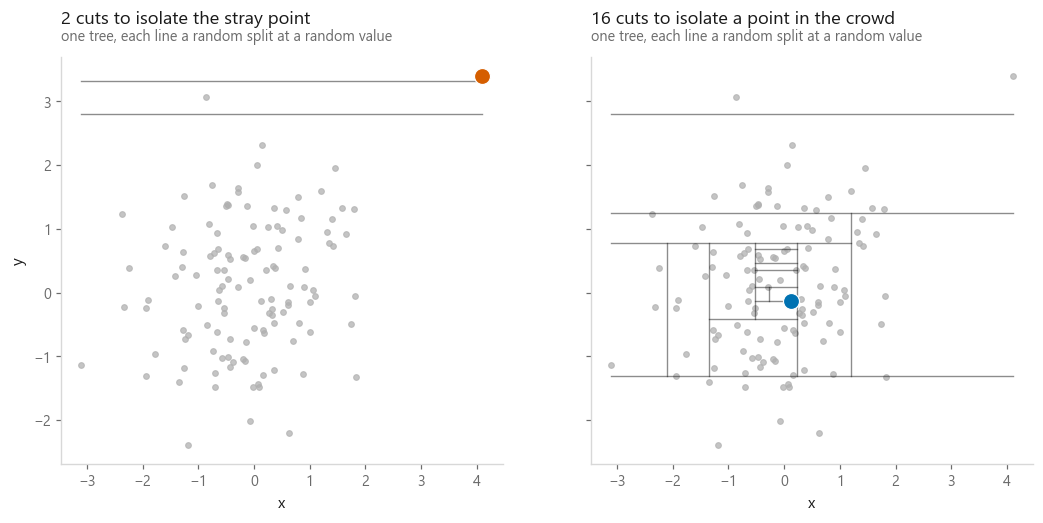

In [2]:
rng = np.random.default_rng(SEED)

cloud = rng.normal(0, 1, (120, 2))
stray = np.array([[4.1, 3.4]])
toy = np.vstack([cloud, stray])
STRAY = len(toy) - 1
CENTRAL = int(np.argmin(np.linalg.norm(cloud, axis=1)))


def isolation_path(points, target, rng, max_depth=60):
    """Random axis-aligned cuts until `target` is alone. Returns the cuts made.

    Each cut is (feature, value, box_low, box_high) so the drawing code knows how
    far to extend the line: a split only exists inside the box it was made in.
    """
    lo, hi = points.min(axis=0).astype(float), points.max(axis=0).astype(float)
    idx = np.arange(len(points))
    cuts = []
    for _ in range(500):
        if idx.size <= 1 or len(cuts) >= max_depth:
            break
        f = int(rng.integers(0, points.shape[1]))
        span_lo, span_hi = points[idx, f].min(), points[idx, f].max()
        if span_hi <= span_lo:
            continue
        v = float(rng.uniform(span_lo, span_hi))
        keep = (points[idx, f] < v) if points[target, f] < v else (points[idx, f] >= v)
        if keep.all():
            continue  # a split that separates nothing is not a step
        cuts.append((f, v, lo.copy(), hi.copy()))
        if points[target, f] < v:
            hi[f] = v
        else:
            lo[f] = v
        idx = idx[keep]
    return cuts


fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.8), sharex=True, sharey=True)

for ax, target, label, colour in [(axes[0], STRAY, "the stray point", style.HIGHLIGHT),
                                  (axes[1], CENTRAL, "a point in the crowd", style.PALETTE[0])]:
    cuts = isolation_path(toy, target, np.random.default_rng(SEED + 7))
    ax.scatter(toy[:, 0], toy[:, 1], s=14, c=style.NEUTRAL, alpha=0.75, zorder=2)
    ax.scatter(toy[target, 0], toy[target, 1], s=110, c=colour, marker=style.MARKERS[0],
               edgecolor="white", linewidth=0.8, zorder=4)
    for f, v, lo, hi in cuts:
        if f == 0:
            ax.plot([v, v], [lo[1], hi[1]], color=style.INK, lw=0.9, alpha=0.5, zorder=3)
        else:
            ax.plot([lo[0], hi[0]], [v, v], color=style.INK, lw=0.9, alpha=0.5, zorder=3)
    ax.set_xlabel("x")
    style.title(ax, f"{len(cuts)} cuts to isolate {label}",
                "one tree, each line a random split at a random value")

axes[0].set_ylabel("y")
for ax in axes:
    ax.grid(visible=False)
style.save(fig, FIG / "fig-01-isolation-paths.png")

trials = {name: np.mean([len(isolation_path(toy, t, rng)) for _ in range(200)])
          for name, t in [("stray point", STRAY), ("central point", CENTRAL)]}
for name, depth in trials.items():
    print(f"{name:>14}: {depth:5.2f} cuts on average over 200 random trees")
print(f"ratio: the central point takes {trials['central point'] / trials['stray point']:.1f}x as many")

The stray point falls out almost immediately, because most random cuts already
have it on one side by itself. The central point survives cut after cut, because
it is surrounded. Average that depth over a few hundred trees and you have an
anomaly score with no distance metric, no scaling, and no assumption about shape.
That is why Isolation Forest is the cheapest thing to try first.

## 3. Drawn on 2-D data

Two blobs of different widths, plus points scattered uniformly over the whole
square. I know which points are noise here, which is the only reason I can check
the answer. On real data I would not.

30 uniform points hidden among 370 blob points, each detector allowed 32 flags

     Isolation Forest: caught 22/30 noise points, and wrongly flagged 10 blob points
        One-Class SVM: caught 21/30 noise points, and wrongly flagged 12 blob points
 Local Outlier Factor: caught 19/30 noise points, and wrongly flagged 13 blob points
     Gaussian mixture: caught 22/30 noise points, and wrongly flagged 10 blob points


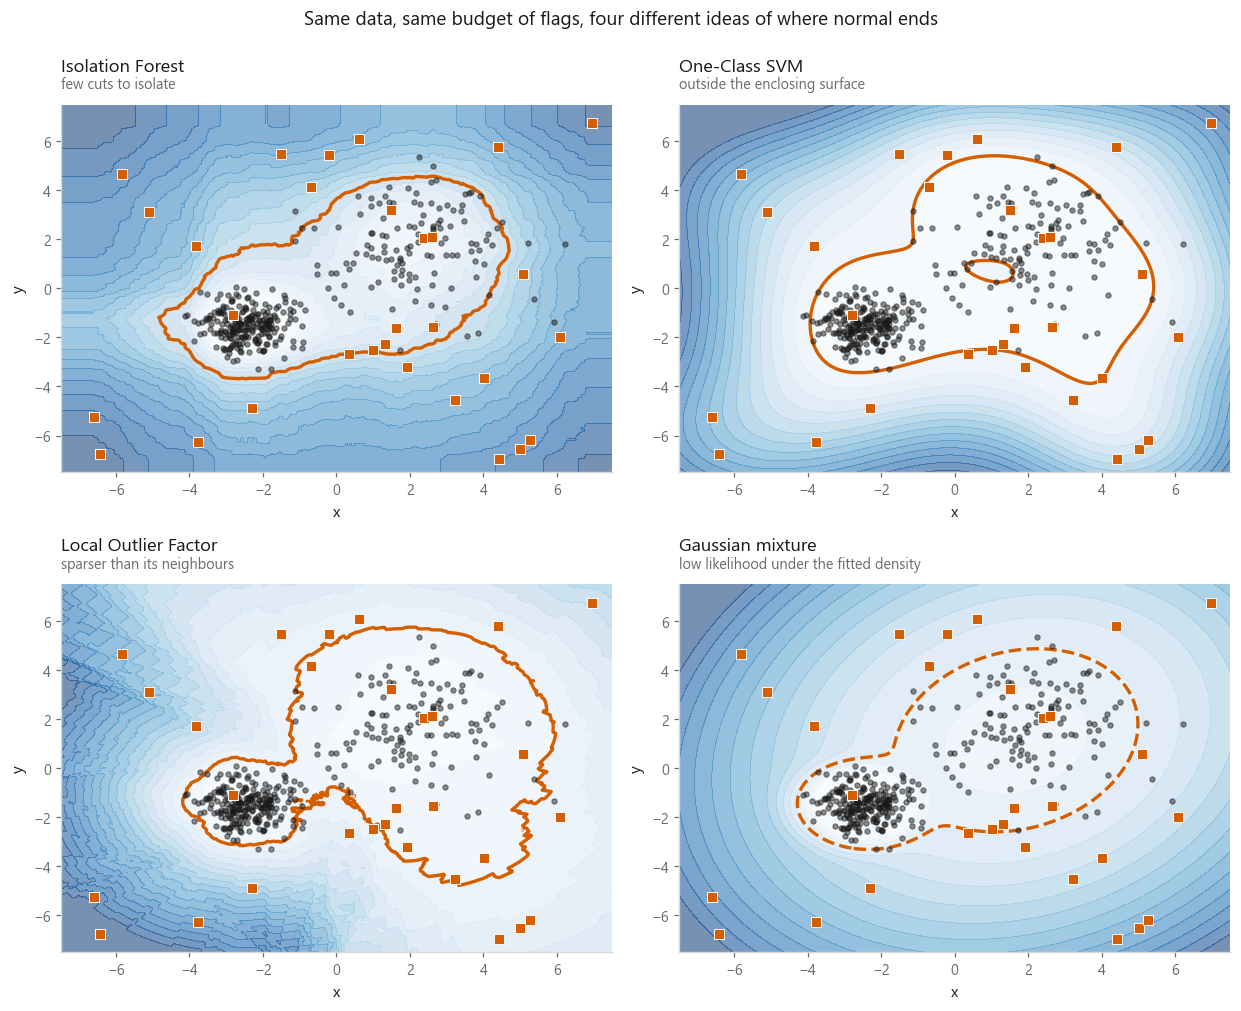

In [3]:
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

CONTAM = 0.08

blobs, _ = make_blobs(n_samples=[240, 130], centers=[(-2.4, -1.5), (2.3, 1.9)],
                      cluster_std=[0.65, 1.45], random_state=SEED)
noise = np.random.default_rng(SEED).uniform(-7, 7, (30, 2))
X2 = np.vstack([blobs, noise])
is_noise = np.r_[np.zeros(len(blobs), bool), np.ones(len(noise), bool)]

grid_x, grid_y = np.meshgrid(np.linspace(-7.5, 7.5, 260), np.linspace(-7.5, 7.5, 260))
grid = np.c_[grid_x.ravel(), grid_y.ravel()]

iforest2 = IsolationForest(n_estimators=300, contamination=CONTAM, random_state=SEED).fit(X2)
ocsvm2 = OneClassSVM(kernel="rbf", gamma="scale", nu=CONTAM).fit(X2)
# LOF needs novelty=True before it will score points it was not fitted on, such as
# a grid. With novelty=False it only exposes scores for the training rows.
lof2 = LocalOutlierFactor(n_neighbors=20, contamination=CONTAM, novelty=True).fit(X2)
gmm2 = GaussianMixture(n_components=2, covariance_type="full", random_state=SEED).fit(X2)

surfaces = [
    ("Isolation Forest", iforest2.decision_function(grid), 0.0, "few cuts to isolate"),
    ("One-Class SVM", ocsvm2.decision_function(grid), 0.0, "outside the enclosing surface"),
    ("Local Outlier Factor", lof2.decision_function(grid), 0.0, "sparser than its neighbours"),
    ("Gaussian mixture", gmm2.score_samples(grid),
     float(np.quantile(gmm2.score_samples(X2), CONTAM)), "low likelihood under the fitted density"),
]

fig, axes = plt.subplots(2, 2, figsize=(11.4, 9.2))
for ax, (name, raw, cut, blurb) in zip(axes.ravel(), surfaces):
    Z = raw.reshape(grid_x.shape)
    # Log-likelihood runs to enormous negatives in the corners, so the shading is
    # clipped to the middle of its own range or every panel would be one flat colour.
    low, high = np.quantile(Z, [0.02, 0.98])
    ax.contourf(grid_x, grid_y, np.clip(Z, low, high), levels=16, cmap="Blues_r", alpha=0.55)
    ax.contour(grid_x, grid_y, Z, levels=[cut], colors=[style.HIGHLIGHT], linewidths=2.2)
    ax.scatter(X2[~is_noise, 0], X2[~is_noise, 1], s=12, c=style.INK, alpha=0.5, zorder=3)
    ax.scatter(X2[is_noise, 0], X2[is_noise, 1], s=46, c=style.HIGHLIGHT, marker=style.MARKERS[1],
               edgecolor="white", linewidth=0.6, zorder=4)
    ax.grid(visible=False)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    style.title(ax, name, blurb)

fig.suptitle("Same data, same budget of flags, four different ideas of where normal ends",
             x=0.5, y=0.995, fontsize=12.5, color=style.INK)
fig.tight_layout()
style.save(fig, FIG / "fig-02-decision-surfaces.png")

flags = {
    "Isolation Forest": iforest2.predict(X2) == -1,
    "One-Class SVM": ocsvm2.predict(X2) == -1,
    # novelty=False is the mode that labels the training rows themselves.
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=20, contamination=CONTAM)
                            .fit_predict(X2) == -1,
    "Gaussian mixture": gmm2.score_samples(X2) < np.quantile(gmm2.score_samples(X2), CONTAM),
}
print(f"{len(noise)} uniform points hidden among {len(blobs)} blob points, "
      f"each detector allowed {int(round(CONTAM * len(X2)))} flags\n")
for name, flagged in flags.items():
    print(f"{name:>21}: caught {flagged[is_noise].sum():>2}/{is_noise.sum()} noise points, "
          f"and wrongly flagged {flagged[~is_noise].sum():>2} blob points")

The orange line is where each detector stops calling points normal, and the four
lines are not the same shape at all.

Isolation Forest draws a boxy region, because it can only cut along the axes.
The One-Class SVM draws a smooth contour that wraps both blobs and the gap between
them. Local Outlier Factor produces something that hugs each blob separately and
is happy to sit tight around the narrow one and loose around the wide one, which
is the point of a *local* method. The mixture draws two clean ellipses, which is
either exactly right or badly wrong depending on whether the data really is two
ellipses. Here it is, because I generated it that way.

Look at the noise points that landed inside a blob. No detector can flag those,
and none should: nothing about them is observably unusual. The ceiling on this
problem is set by the data, not by the method.

## 4. Scored on a labelled problem

The bean dataset gives me a clean way to build an honest test. I take one common
variety as normal, drop in a handful of a different variety, and throw the labels
in a drawer until it is time to score. The detectors never see them.

In [4]:
from sklearn.preprocessing import StandardScaler

beans, variety = datasets.dry_bean()
print(variety.value_counts().to_string(), "\n")

NORMAL, RARE, N_RARE = "DERMASON", "BARBUNYA", 40

normal_rows = beans[variety == NORMAL]
rare_rows = beans[variety == RARE].sample(N_RARE, random_state=SEED)

bean_raw = np.vstack([normal_rows.to_numpy(), rare_rows.to_numpy()])
bean_y = np.r_[np.zeros(len(normal_rows), int), np.ones(N_RARE, int)]
order = np.random.default_rng(SEED).permutation(len(bean_y))
bean_raw, bean_y = bean_raw[order], bean_y[order]

# Three of the four measure distance in some form, so units matter to them. Isolation
# Forest is indifferent, but there is no harm in giving everyone the same matrix.
bean_X = StandardScaler().fit_transform(bean_raw)

print(f"normal class : {NORMAL:>9}  {(bean_y == 0).sum():>5} rows")
print(f"anomalies    : {RARE:>9}  {(bean_y == 1).sum():>5} rows")
print(f"base rate    : {bean_y.mean():.4%}  <- a detector flagging at random scores this")

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522 

normal class :  DERMASON   3546 rows
anomalies    :  BARBUNYA     40 rows
base rate    : 1.1154%  <- a detector flagging at random scores this


### First, without labels

Pretend the drawer is locked. What can I say about a detector with nothing to
check it against? Three things, and none of them is correctness.

The first is **stability**. Refit with a different seed, or a different
neighbourhood size, and see whether the same rows come back. A detector whose top
flags reshuffle every run is telling me about its own randomness.

In [5]:
K = int(bean_y.sum())  # flag exactly as many rows as there really are anomalies


def top_set(scores, k=K):
    return set(np.argsort(-scores)[:k].tolist())


forest_seeds = [-IsolationForest(n_estimators=300, random_state=s).fit(bean_X).score_samples(bean_X)
                for s in range(4)]
lof_ks = [(k, -LocalOutlierFactor(n_neighbors=k).fit(bean_X).negative_outlier_factor_)
          for k in [10, 20, 40, 80]]

base_forest = top_set(forest_seeds[0])
print(f"top-{K} overlap across Isolation Forest seeds (its randomness):")
for s, sc in enumerate(forest_seeds[1:], start=1):
    print(f"  seed 0 vs seed {s}: {len(base_forest & top_set(sc)) / K:.0%}")

base_lof = top_set(lof_ks[1][1])
print(f"\ntop-{K} overlap across LOF neighbourhood sizes (no randomness, all choice):")
for k, sc in lof_ks:
    if k != 20:
        print(f"  k=20 vs k={k:>2}: {len(base_lof & top_set(sc)) / K:.0%}")

top-40 overlap across Isolation Forest seeds (its randomness):
  seed 0 vs seed 1: 98%
  seed 0 vs seed 2: 95%
  seed 0 vs seed 3: 98%

top-40 overlap across LOF neighbourhood sizes (no randomness, all choice):
  k=20 vs k=10: 72%
  k=20 vs k=40: 70%
  k=20 vs k=80: 12%


Isolation Forest is random and LOF is not, yet LOF's answer moves too, because $k$
is a decision and every value of it is a different question. Neither number tells
me anything about whether the flagged beans are the odd variety. It tells me how
much of the answer is the method's own noise.

The second check is **whether the score has resolution at all**. Scatter points
uniformly across the same box the data lives in and score them with the fitted
detector. If uniform junk scores like real rows, the detector has not learned the
shape of anything.

The third is **reading the flagged rows**. If the flagged group differs from the
rest in a way I can name, I have something to take to whoever owns the data.

In [6]:
forest = IsolationForest(n_estimators=300, random_state=SEED).fit(bean_X)
real_score = -forest.score_samples(bean_X)

junk = np.random.default_rng(SEED).uniform(bean_X.min(axis=0), bean_X.max(axis=0),
                                           (2000, bean_X.shape[1]))
junk_score = -forest.score_samples(junk)
threshold = np.quantile(real_score, 0.99)
print(f"share of real rows above the 99th percentile : {(real_score >= threshold).mean():.1%}")
print(f"share of uniform junk above the same cut     : {(junk_score >= threshold).mean():.1%}")
print("(if those two were equal the score would be carrying no information)\n")

flagged = real_score >= np.quantile(real_score, 1 - K / len(bean_y))
profile = pd.DataFrame(bean_X, columns=beans.columns)
gap = profile[flagged].mean() - profile[~flagged].mean()
print("features where the flagged rows differ most, in standard deviations:")
print(gap.reindex(gap.abs().sort_values(ascending=False).index).head(5).round(2).to_string())

share of real rows above the 99th percentile : 1.0%
share of uniform junk above the same cut     : 88.6%
(if those two were equal the score would be carrying no information)

features where the flagged rows differ most, in standard deviations:
ConvexArea         5.32
Area               5.26
Perimeter          5.10
EquivDiameter      4.53
MinorAxisLength    4.33


That last table is the honest deliverable of a label-free run. It does not say the
flagged beans are wrong. It says what makes them different, in units someone can
argue with. Everything else I have printed so far measures self-consistency, and a
detector can be perfectly self-consistent about the wrong thing.

### Now with labels, honestly

With labels back on the table, the metric matters more than usual. Accuracy is
useless here: calling everything normal scores over ninety-nine percent on this
problem. ROC AUC is better but still flattering, because the enormous normal class
dominates the false-positive rate and hides how much rubbish sits at the top of the
ranking.

**Average precision** is the one to report. It is the area under the
precision-recall curve, it only ever looks at the ranking above each threshold, and
its no-skill value is the base rate itself. On this problem that floor is very low,
so any score well above it is real. I run the same four detectors on the bean
problem and on a second one built the same way from the breast cancer data, because
one dataset is an anecdote.

In [7]:
from sklearn.metrics import average_precision_score


def fit_detectors(X, seed=SEED, gmm_components=3, svm_rows=3000, nu=0.1, n_neighbors=20):
    """All four detectors on one scaled matrix. Every score: higher means stranger.

    One-Class SVM is quadratic in rows, so it is fitted on a subsample and then used
    to score everything. The other three are cheap enough to fit on the lot.
    """
    sub = np.random.default_rng(seed).choice(len(X), min(svm_rows, len(X)), replace=False)
    models = {
        "Isolation Forest": IsolationForest(n_estimators=300, random_state=seed).fit(X),
        "One-Class SVM": OneClassSVM(kernel="rbf", gamma="scale", nu=nu).fit(X[sub]),
        "Local Outlier Factor": LocalOutlierFactor(n_neighbors=n_neighbors).fit(X),
        # reg_covar shrinks the covariances a little. Without it, a full covariance
        # over correlated shape features goes singular and the likelihood is fiction.
        "Gaussian mixture": GaussianMixture(n_components=gmm_components, covariance_type="full",
                                            reg_covar=1e-2, max_iter=500,
                                            random_state=seed).fit(X),
    }
    scores = {
        "Isolation Forest": -models["Isolation Forest"].score_samples(X),
        "One-Class SVM": -models["One-Class SVM"].score_samples(X),
        "Local Outlier Factor": -models["Local Outlier Factor"].negative_outlier_factor_,
        "Gaussian mixture": -models["Gaussian mixture"].score_samples(X),
    }
    return models, scores


bean_models, bean_scores = fit_detectors(bean_X, gmm_components=3)
bean_ap = {name: average_precision_score(bean_y, s) for name, s in bean_scores.items()}

cells, diagnosis = datasets.breast_cancer()  # 1 = benign, 0 = malignant
cell_raw = np.vstack([cells[diagnosis == 1].to_numpy(),
                      cells[diagnosis == 0].sample(18, random_state=SEED).to_numpy()])
cell_y = np.r_[np.zeros((diagnosis == 1).sum(), int), np.ones(18, int)]
cell_X = StandardScaler().fit_transform(cell_raw)

_, cell_scores = fit_detectors(cell_X, gmm_components=2)
cell_ap = {name: average_precision_score(cell_y, s) for name, s in cell_scores.items()}

for label, aps, y in [("dry bean", bean_ap, bean_y), ("breast cancer", cell_ap, cell_y)]:
    print(f"{label}  (base rate {y.mean():.3f})")
    for name, value in sorted(aps.items(), key=lambda kv: -kv[1]):
        print(f"   {name:>21}: average precision {value:.3f}   "
              f"({value / y.mean():.0f}x the base rate)")
    print()

dry bean  (base rate 0.011)
        Isolation Forest: average precision 0.949   (85x the base rate)
           One-Class SVM: average precision 0.537   (48x the base rate)
        Gaussian mixture: average precision 0.128   (11x the base rate)
    Local Outlier Factor: average precision 0.077   (7x the base rate)

breast cancer  (base rate 0.048)
        Isolation Forest: average precision 0.617   (13x the base rate)
    Local Outlier Factor: average precision 0.476   (10x the base rate)
           One-Class SVM: average precision 0.356   (7x the base rate)
        Gaussian mixture: average precision 0.225   (5x the base rate)



best on each problem: {'dry bean': 'Isolation Forest', 'breast cancer': 'Isolation Forest'}
same winner on both? True


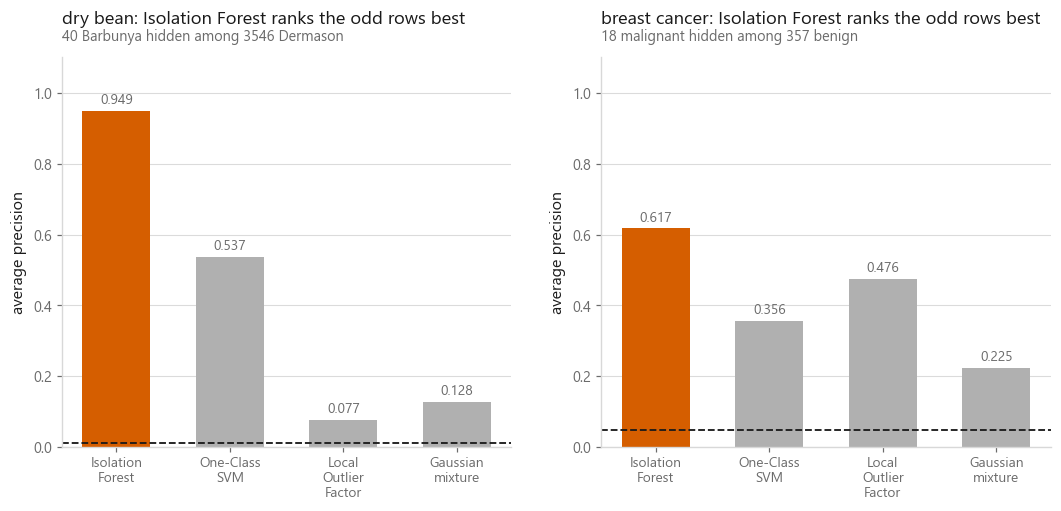

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))

for ax, (label, aps, y, sub) in zip(axes, [
        ("dry bean", bean_ap, bean_y, f"{N_RARE} {RARE.title()} hidden among {(bean_y == 0).sum()} {NORMAL.title()}"),
        ("breast cancer", cell_ap, cell_y, f"{int(cell_y.sum())} malignant hidden among {int((cell_y == 0).sum())} benign")]):
    names = list(aps)
    values = [aps[n] for n in names]
    ax.bar(range(len(names)), values, color=style.spot(len(names), int(np.argmax(values))), width=0.6)
    ax.axhline(y.mean(), color=style.INK, ls="--", lw=1.2)
    ax.annotate("flagging at random", xy=(len(names) - 0.45, y.mean()),
                xytext=(0, 4), textcoords="offset points", ha="right", va="bottom",
                fontsize=9, color=style.MUTED)
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9, color=style.MUTED)
    ax.set_xticks(range(len(names)), [n.replace(" ", "\n") for n in names], fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("average precision")
    ax.grid(axis="x", visible=False)
    style.title(ax, f"{label}: {names[int(np.argmax(values))]} ranks the odd rows best", sub)

style.save(fig, FIG / "fig-03-average-precision.png")

winners = {lbl: max(aps, key=aps.get) for lbl, aps in [("dry bean", bean_ap), ("breast cancer", cell_ap)]}
print("best on each problem:", winners)
print("same winner on both?", len(set(winners.values())) == 1)

Two things to take from that chart. Every detector clears the random floor by a
wide margin, so all four found something. And the ordering is not the same on the
two problems, which is the ordinary result and the reason I am suspicious of any
blog post that names a best anomaly detector.

The two problems differ in a way that explains most of it. The bean anomalies are
a different variety, so they are shifted in a few shape features and sit in their
own small clump — a clump is exactly what a *local* method has trouble with, since
a tight group of forty is not sparse relative to itself. The malignant cells are
spread out along several correlated measurements, which suits a density model. The
structure of the anomaly decides the winner, and you usually cannot see that
structure before you pick the detector.

## 5. Where they disagree, and the contamination parameter

Since the four measure different things, the interesting question is not which one
is right but where they part company.

In [9]:
from scipy.stats import rankdata, spearmanr

names = list(bean_scores)
rho = spearmanr(np.column_stack([bean_scores[n] for n in names])).statistic

tops = {n: top_set(bean_scores[n]) for n in names}
counts = np.zeros(len(bean_y), int)
for s in tops.values():
    counts[list(s)] += 1

unanimous = np.flatnonzero(counts == 4)
lonely = np.flatnonzero(counts == 1)
print(f"each detector flagged its top {K} rows")
print(f"  rows all four agreed on : {len(unanimous):>3}   of which really anomalies: "
      f"{bean_y[unanimous].sum()}")
print(f"  rows only one flagged   : {len(lonely):>3}   of which really anomalies: "
      f"{bean_y[lonely].sum()}")

# Averaging ranks is the cheapest possible ensemble and needs no labels to build.
consensus = np.mean([rankdata(bean_scores[n]) for n in names], axis=0)
ap_consensus = average_precision_score(bean_y, consensus)
print(f"\naverage precision, rank-average of all four : {ap_consensus:.3f}")
print(f"average precision, best single detector     : {max(bean_ap.values()):.3f}")
print(f"average precision, worst single detector    : {min(bean_ap.values()):.3f}")

each detector flagged its top 40 rows
  rows all four agreed on :   3   of which really anomalies: 0
  rows only one flagged   :  56   of which really anomalies: 18

average precision, rank-average of all four : 0.087
average precision, best single detector     : 0.949
average precision, worst single detector    : 0.077


Unanimous flags are the ones worth acting on first. Rows that only one detector
noticed are worth a different kind of attention: they are usually strange in the
specific way that one detector measures, and looking at which detector caught them
tells you what kind of strange it is. A row flagged only by LOF is in a local
hole; a row flagged only by the mixture is in a low-density tail. Disagreement is
a diagnosis, not a problem to average away.

### Contamination, where you tell the model the answer

`contamination` looks like a modelling choice. It is not. For Isolation Forest and
LOF it does exactly one thing: it sets the cutoff on a score that was already
computed, by taking that quantile of the training scores. The ranking does not
move. Everything below is computed by thresholding a single fit at different
quantiles, and then checked against what scikit-learn does when it refits.

contamination=0.01  flags   36 rows  precision 0.917  recall 0.825  | largest change in any score vs the default fit: 0.00e+00


contamination=0.05  flags  180 rows  precision 0.217  recall 0.975  | largest change in any score vs the default fit: 0.00e+00


contamination=0.2   flags  717 rows  precision 0.056  recall 1.000  | largest change in any score vs the default fit: 0.00e+00


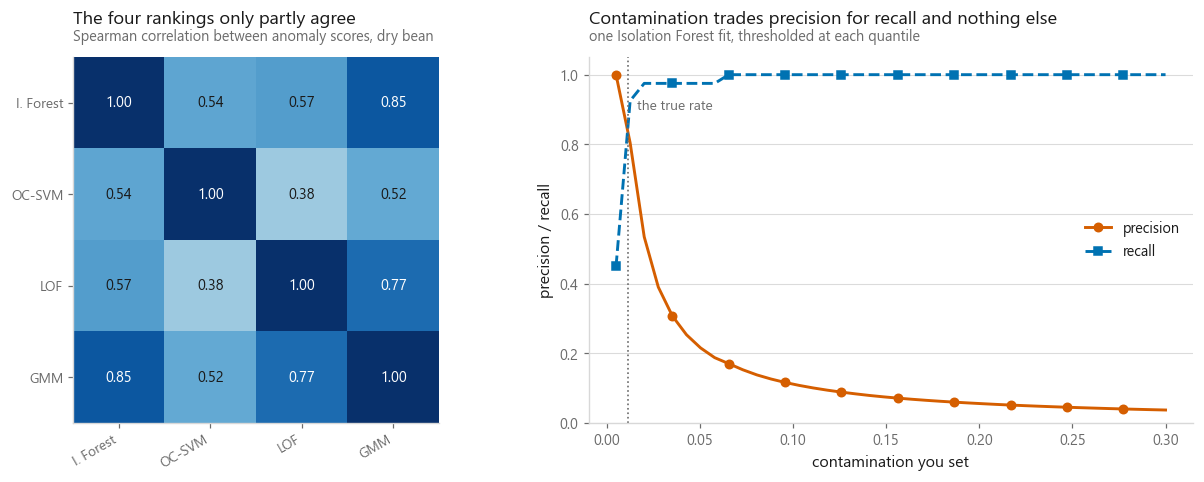

In [10]:
score = bean_scores["Isolation Forest"]
sweep = np.linspace(0.005, 0.30, 40)
precision = [bean_y[score >= np.quantile(score, 1 - c)].mean() for c in sweep]
recall = [bean_y[score >= np.quantile(score, 1 - c)].sum() / bean_y.sum() for c in sweep]

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))

axes[0].imshow(rho, cmap="Blues", vmin=0, vmax=1)
short = ["I. Forest", "OC-SVM", "LOF", "GMM"]
axes[0].set_xticks(range(len(names)), short, fontsize=9, rotation=30, ha="right")
axes[0].set_yticks(range(len(names)), short, fontsize=9)
for i in range(len(names)):
    for j in range(len(names)):
        axes[0].text(j, i, f"{rho[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                     color="white" if rho[i, j] > 0.6 else style.INK)
axes[0].grid(visible=False)
style.title(axes[0], "The four rankings only partly agree",
            "Spearman correlation between anomaly scores, dry bean")

axes[1].plot(sweep, precision, marker=style.MARKERS[0], markevery=4,
             color=style.HIGHLIGHT, label="precision")
axes[1].plot(sweep, recall, marker=style.MARKERS[1], markevery=4,
             color=style.PALETTE[0], ls="--", label="recall")
axes[1].axvline(bean_y.mean(), color=style.MUTED, lw=1.1, ls=":")
axes[1].annotate("the true rate", xy=(bean_y.mean(), 0.9), xytext=(6, 0),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
axes[1].set_xlabel("contamination you set")
axes[1].set_ylabel("precision / recall")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
style.title(axes[1], "Contamination trades precision for recall and nothing else",
            "one Isolation Forest fit, thresholded at each quantile")

fig.tight_layout()
style.save(fig, FIG / "fig-04-disagreement-and-contamination.png")

base = IsolationForest(n_estimators=300, random_state=SEED).fit(bean_X)
for c in [0.01, 0.05, 0.20]:
    refit = IsolationForest(n_estimators=300, contamination=c, random_state=SEED).fit(bean_X)
    drift = np.abs(refit.score_samples(bean_X) - base.score_samples(bean_X)).max()
    flagged_c = refit.predict(bean_X) == -1
    print(f"contamination={c:<5} flags {flagged_c.sum():>4} rows  "
          f"precision {bean_y[flagged_c].mean():.3f}  recall {flagged_c[bean_y == 1].mean():.3f}  "
          f"| largest change in any score vs the default fit: {drift:.2e}")

The scores do not move at all. Only the line drawn through them moves. So
`contamination` is not a parameter of the model, it is your prior about how many
anomalies exist, entered as a number and then handed back to you as a result. If
you set it to the true rate you will look accurate, and the only reason you knew
the true rate is that you had labels, in which case you had better options.

The One-Class SVM is the exception worth knowing, because `nu` enters the
optimisation itself.

In [11]:
sub = np.random.default_rng(SEED).choice(len(bean_X), 3000, replace=False)
tight = OneClassSVM(kernel="rbf", gamma="scale", nu=0.01).fit(bean_X[sub])
loose = OneClassSVM(kernel="rbf", gamma="scale", nu=0.20).fit(bean_X[sub])

print(f"nu=0.01 -> {len(tight.support_):>5} support vectors, "
      f"average precision {average_precision_score(bean_y, -tight.score_samples(bean_X)):.3f}")
print(f"nu=0.20 -> {len(loose.support_):>5} support vectors, "
      f"average precision {average_precision_score(bean_y, -loose.score_samples(bean_X)):.3f}")
print(f"Spearman between the two rankings: "
      f"{spearmanr(tight.score_samples(bean_X), loose.score_samples(bean_X)).statistic:.4f}")

nu=0.01 ->   101 support vectors, average precision 0.186


nu=0.20 ->   607 support vectors, average precision 0.568


Spearman between the two rankings: 0.6573


Two different fits, two different rankings, and the average precision changes with
them. For the SVM the dial is real and needs tuning; for the other three it is
cosmetic. That difference is easy to miss because scikit-learn spells both of them
as one small float in the constructor.

My practical advice is to leave `contamination="auto"` on, work with the raw scores
from `score_samples`, and pick the cutoff at the end from something outside the
model: how many alerts a person can actually read in a day, or what a false alarm
costs. That is a capacity decision, and pretending it is a hyperparameter does not
make it one.

## Cheat sheet

| | |
|---|---|
| **Try first** | Isolation Forest. No scaling, near-linear in rows, few knobs, and hard to make actively bad |
| **Local structure** | Local Outlier Factor, when density varies across the data and "unusual" means unusual for its own neighbourhood. Set `novelty=True` before scoring rows it was not fitted on |
| **Small and clean** | One-Class SVM, under a few thousand rows, on scaled features. It is quadratic, so subsample before fitting and score everything afterwards |
| **When you can defend the shape** | A Gaussian mixture, which gives a real likelihood you can reason about. Regularise the covariances or it will go singular in high dimensions |
| **Scaling** | Everything except Isolation Forest needs it. Fit the scaler on the normal data only |
| **Metric** | Average precision, with the base rate quoted next to it. Accuracy is meaningless at these class ratios and ROC AUC flatters |
| **Contamination** | A threshold on a fixed ranking for Isolation Forest and LOF. `nu` in a One-Class SVM changes the fit. Neither is a way to discover how many anomalies you have |
| **No labels** | Check stability across seeds and neighbourhood sizes, check the score separates real rows from uniform junk, and describe the flagged rows in feature terms |
| **Next** | [Association rules](../07-association-rules/), which look for the combinations that turn up together rather than the rows that stand apart |

## What to remember

1. Four detectors, four definitions of unusual: short isolation path, outside a
   boundary, sparse relative to your neighbours, low likelihood. They are not
   approximations of one another.
2. The shape of the anomaly picks the winner. A tight clump of odd rows defeats a
   local method; a diffuse tail suits a density model. You rarely know which you
   have in advance.
3. Score with average precision and print the base rate beside it, so nobody
   mistakes a large number for a good one.
4. Without labels you can measure stability, resolution against generated junk, and
   whether the flagged rows have a describable difference. None of that is
   correctness, and it is dishonest to present it as such.
5. `contamination` moves a threshold on a ranking that was already fixed. Setting
   it to the right answer is not the model finding the right answer.
6. Where detectors disagree is where the information is. Unanimous flags are the
   safe ones; a lone flag tells you which kind of strange you are looking at.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [05-07 Association rules with Apriori](../07-association-rules/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#AnomalyDetection` `#OutlierDetection` `#IsolationForest`
`#OneClassSVM` `#LocalOutlierFactor` `#Python` `#ScikitLearn` `#DataScience`
`#MLTutorial`